In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

Making a regression data with make_regression function.

In [3]:
X,y = make_regression(n_samples=200,n_features=1,n_targets=1,noise=20,random_state=11)

Visualizing dataset.

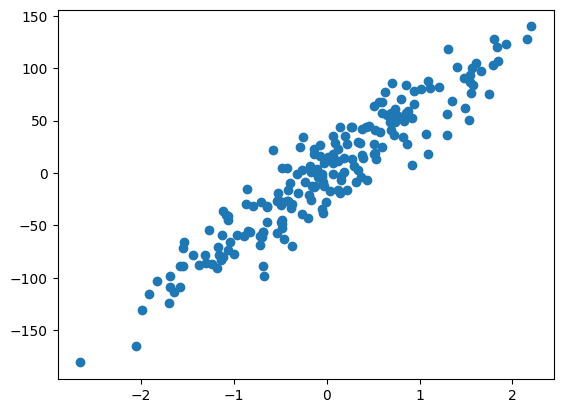

In [4]:
plt.scatter(X,y)
plt.show()

Changing the linear data X to nonlinear.

In [5]:
X = ((X + 5) ** 3) / 2

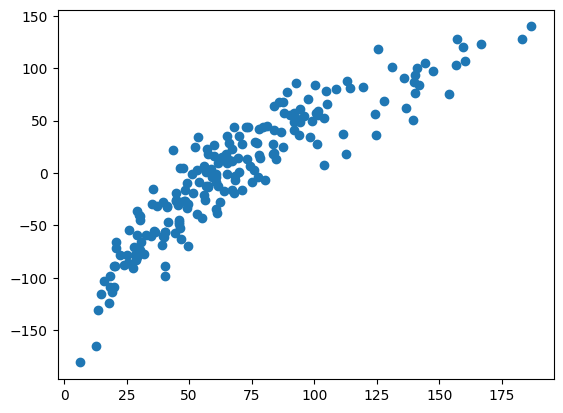

In [6]:
plt.scatter(X,y)
plt.show()

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,random_state=123)

In [8]:
LR = LinearRegression()
LR.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
LR.score(X_train,y_train)

0.8124082875087931

In [10]:
LR.score(X_test,y_test)

0.8532330136044993

In [11]:
y_pred_test = LR.predict(X_test)
y_pred_train = LR.predict(X_train)

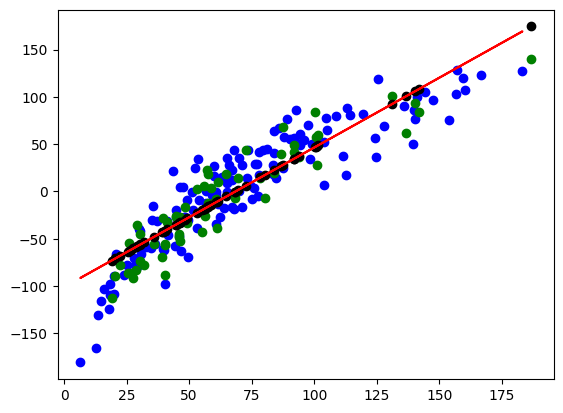

In [12]:
plt.scatter(X_train,y_train,color="blue")
plt.plot(X_train,y_pred_train,color="red")
plt.scatter(X_test,y_test,color="green")
plt.scatter(X_test,y_pred_test,color="black")
plt.show()

This helping the regressor to learn the nonelinear features better.

In [13]:
from sklearn.preprocessing import PolynomialFeatures

In [14]:
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.30,random_state=123)

In [16]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
model.score(X_train,y_train)

0.8841410300948959

In [18]:
model.score(X_test,y_test)

0.8881659449540104

Now we see that our scores improved on regression we made. its because of that we helped regressor to learn the nonelinear features with PolynomialFeatures method.

In [19]:
x_sample = np.array([180])

In [20]:
x_sample = poly.transform([x_sample])

In [21]:
model.predict(x_sample)

array([134.3826781])

In [22]:
X_poly.shape

(200, 4)

In [23]:
X_poly[:5]

array([[1.00000000e+00, 7.60816559e+01, 5.78841837e+03, 4.40392455e+05],
       [1.00000000e+00, 8.59951015e+01, 7.39515749e+03, 6.35947319e+05],
       [1.00000000e+00, 1.80119515e+01, 3.24430398e+02, 5.84362460e+03],
       [1.00000000e+00, 8.38462446e+01, 7.03019273e+03, 5.89455259e+05],
       [1.00000000e+00, 4.60329440e+01, 2.11903194e+03, 9.75452785e+04]])

In [24]:
X[:5]

array([[76.08165594],
       [85.99510153],
       [18.01195153],
       [83.84624457],
       [46.03294403]])

The coefients of regression function. We eant to use them in manual nonelinear regression made.

In [25]:
a = model.coef_[0]
b = model.coef_[1]
c = model.coef_[2]
d = model.coef_[3]
i = model.intercept_

In [27]:
# y = i + a*(x**0) + b*(x**1) + c*(x**2) + d*(x**3)
# thats the regression function of grade 3 structer. 

In [28]:
y_predict = lambda x:i + a*(x**0) + b*(x**1) + c*(x**2) + d*(x**3)

In [29]:
x_sample = np.array([180])

In [30]:
y_predict(x_sample)

array([134.3826781])

In [31]:
y_pred = model.predict(X_poly)

We can test the NoneLinear regression we made manualy with coeffients and visualize it.

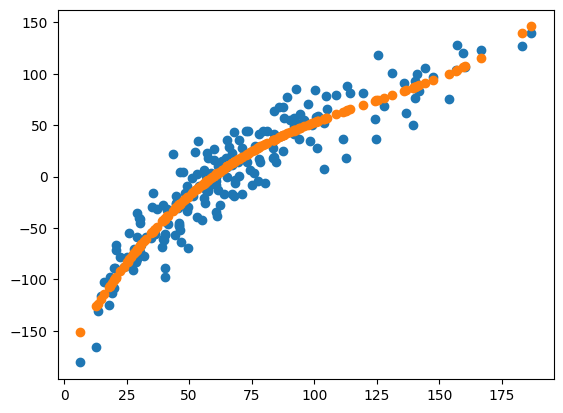

In [32]:
plt.scatter(X,y)
plt.scatter(X,y_pred)
plt.show()

In [33]:
X_poly[:5]

array([[1.00000000e+00, 7.60816559e+01, 5.78841837e+03, 4.40392455e+05],
       [1.00000000e+00, 8.59951015e+01, 7.39515749e+03, 6.35947319e+05],
       [1.00000000e+00, 1.80119515e+01, 3.24430398e+02, 5.84362460e+03],
       [1.00000000e+00, 8.38462446e+01, 7.03019273e+03, 5.89455259e+05],
       [1.00000000e+00, 4.60329440e+01, 2.11903194e+03, 9.75452785e+04]])

In [34]:
X[0:5]

array([[76.08165594],
       [85.99510153],
       [18.01195153],
       [83.84624457],
       [46.03294403]])

In [35]:
# a*(x**0) + b*(x**1) + c*(x**2) + d*(x**3)

In [36]:
model.coef_

array([ 0.00000000e+00,  4.53832771e+00, -3.03542929e-02,  8.24347113e-05])

In [37]:
model.coef_ @ X_poly[0].T + model.intercept_

26.087310462261797

In [38]:
model.predict(X_poly[:1])

array([26.08731046])

In [39]:
X_poly[0:5]

array([[1.00000000e+00, 7.60816559e+01, 5.78841837e+03, 4.40392455e+05],
       [1.00000000e+00, 8.59951015e+01, 7.39515749e+03, 6.35947319e+05],
       [1.00000000e+00, 1.80119515e+01, 3.24430398e+02, 5.84362460e+03],
       [1.00000000e+00, 8.38462446e+01, 7.03019273e+03, 5.89455259e+05],
       [1.00000000e+00, 4.60329440e+01, 2.11903194e+03, 9.75452785e+04]])

In [40]:
X[0:5]

array([[76.08165594],
       [85.99510153],
       [18.01195153],
       [83.84624457],
       [46.03294403]])

In [41]:
np.concatenate([X[0]**0,X[0]**1,X[0]**2,X[0]**3])

array([1.00000000e+00, 7.60816559e+01, 5.78841837e+03, 4.40392455e+05])